In [1]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Union, Tuple, List
from utils import get_random_image


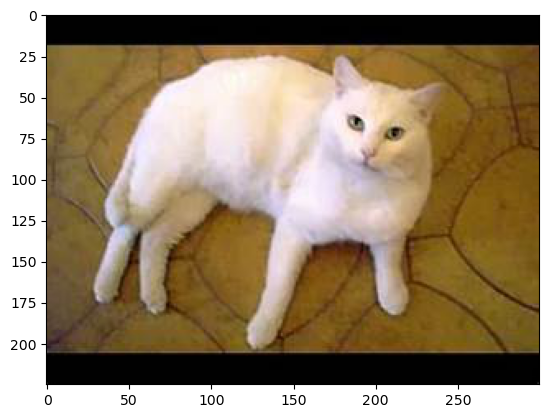

In [2]:
img = get_random_image("cat")
plt.imshow(img, cmap="gray")

### next, lets implement our own manuel convolution class from scratch

In [3]:
class ManualConvolution:
    def __init__(self,image:Union[np.ndarray,str],kernel:np.ndarray,padding:int=0,stride:int=1) -> None:
        if isinstance(image, str):
            try:
                self.image = plt.imread(image)
            except:
                raise Exception("Invalid image path")
        else:
            self.image = image
        print("loaded image:")
        plt.imshow(self.image, cmap="gray")
        plt.show()
        self.img_width, self.img_height, self.img_channels = image.shape
        self.kernel = kernel
        self.kernel_width, self.kernel_height = kernel.shape
        self.padding = padding
        self.stride = stride
        self.out_width = (self.img_width - self.kernel_width + 2 * padding) // stride + 1
        self.out_height = (self.img_height - self.kernel_height + 2 * padding) // stride + 1

        self.output = np.zeros((self.out_width, self.out_height, self.img_channels))
        self.padded_image = np.zeros((self.img_width + 2 * padding, self.img_height + 2 * padding, self.img_channels))
        self.padded_image[padding:self.img_width + padding, padding:self.img_height + padding, :] = self.image

    def convolve(self) -> np.ndarray:
        for channel in range(self.img_channels):
            for y in range(self.out_height):
                for x in range(self.out_width):
                    # index corners of the current window
                    x_start = x * self.stride
                    x_end = x_start + self.kernel_width
                    y_start = y*self.stride
                    y_end = y_start + self.kernel_height
                    current_window = self.padded_image[x_start:x_end, y_start:y_end, channel]
                    # apply the kernel
                    self.output[x, y, channel] = np.sum(np.multiply(current_window, self.kernel))
        plt.imshow(self.output.sum(axis=2), cmap="gray")
        plt.title("Convolution result")
        return self.output

loaded image:


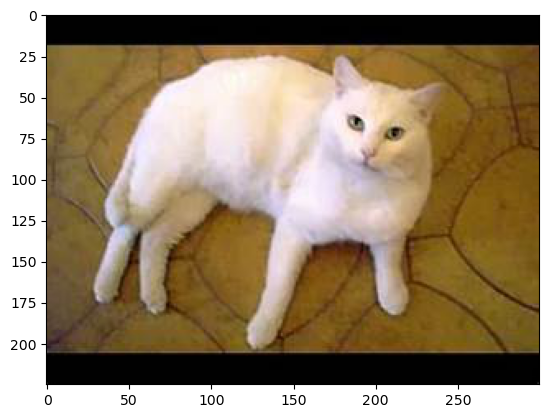

((225, 300, 3), (223, 298, 3))

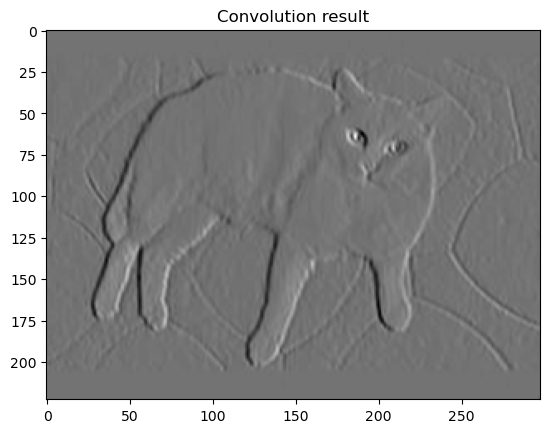

In [4]:
kernel = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
conv = ManualConvolution(img, kernel)
out = conv.convolve()
img.shape, out.shape

loaded image:


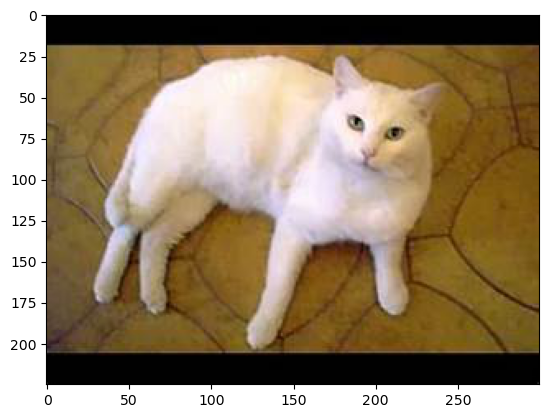

((225, 300, 3), (45, 60, 3))

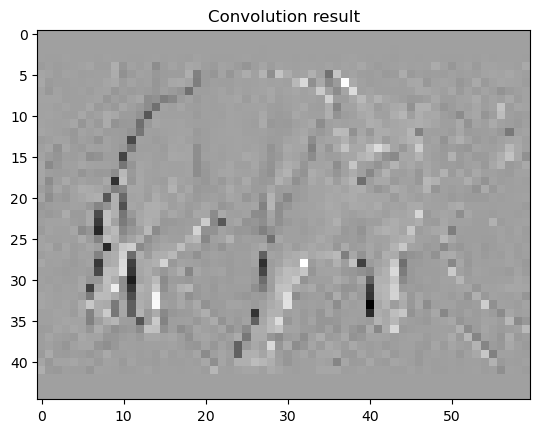

In [8]:
# lets have a stride of 10
conv = ManualConvolution(img, kernel, stride=5)
out = conv.convolve()
img.shape, out.shape

loaded image:


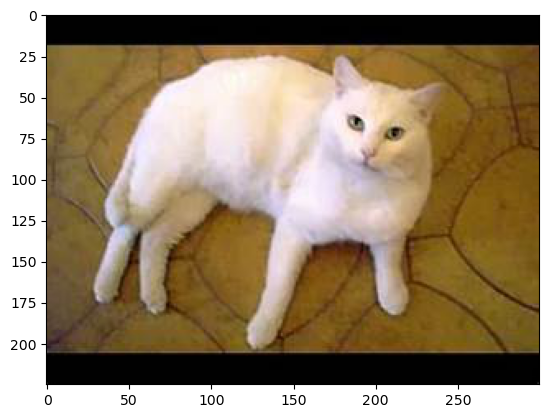

((225, 300, 3), (114, 151, 3))

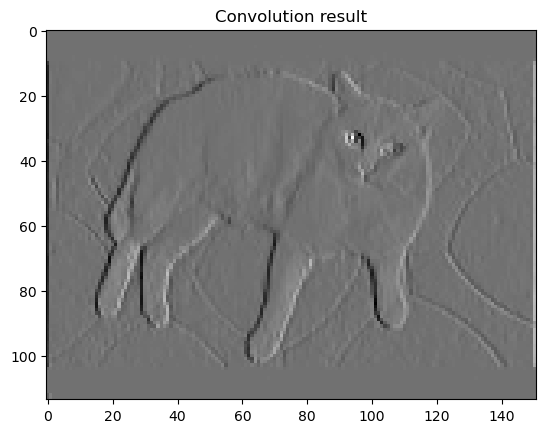

In [9]:
# now lets add padding and stride at the same time
conv = ManualConvolution(img, kernel, padding=2, stride=2)
out = conv.convolve()
img.shape, out.shape

https://www.youtube.com/watch?v=32LHy2JGb30&list=PLf_idrN5yDOWXRXCuvfUBczF1E1tNV85h&index=1&pp=iAQB

### now lets implement our own batch image resizer

In [2]:
from typing import Dict
from PIL import Image
import os
import numpy as np
import glob
import matplotlib.pyplot as plt


class ImageBatchGenerator:
    def __init__(self, data_map:Dict[str,Union[str,List[np.ndarray]]], batch_size:int=32, network_input_size:Tuple[int]=(224,224)) -> None:
        self.batch_size = batch_size
        self.network_input_size = network_input_size
        
        self.data_map = data_map
        self.classes = list(data_map.keys())
        self.class_map = {class_name:idx for idx, class_name in enumerate(self.classes)}

        for key in self.classes:
            if isinstance(data_map[key], str):
                if not os.path.exists(data_map[key]) or not os.path.isdir(data_map[key]):
                    raise Exception(f"Invalid folder path for class {key}")
                self.data_map[key] = glob.glob(data_map[key] + "/*")

        self.class_lengths = {class_name:len(data_map[class_name]) for class_name in self.classes}
        self.all_lengths = list(self.class_lengths.values())
        

        self.labels = {class_name:np.zeros(self.class_lengths[class_name]) + self.class_map[class_name] for class_name in self.classes}
        self.all_labels = np.concatenate(list(self.labels.values()))
        self.all_img_paths = np.concatenate(list(self.data_map.values()))

        self.batch_img_paths, self.batch_labels = self.select_balanced_batch_indices()

        self.network_input_x, self.network_input_y = self.network_input_size

        self.batch_matrix = np.zeros((self.network_input_x, self.network_input_y, 3,self.batch_size))
        for i, img_path in enumerate(self.batch_img_paths):
            img = Image.open(img_path)
            img = img.resize((self.network_input_x, self.network_input_y))
            img = np.array(img)
            if len(img.shape) == 2: # if the image is grayscale
                img = np.stack((img,)*3, axis=-1)
            self.batch_matrix[:, :, :, i] = img # put the image in the batch matrix
        # then at the end make sure its in 8bits representation
        self.batch_matrix = self.batch_matrix.astype("uint8")
        
    def visualize_batch(self) -> None:
        # lets create a grid of square
        grid_size = int(np.ceil(np.sqrt(self.batch_size)))
        _, ax = plt.subplots(grid_size, grid_size, figsize=(20, 20))
        for i in range(self.batch_size):
            img = self.batch_matrix[:, :, :, i]
            x = i // grid_size
            y = i % grid_size
            ax[x, y].imshow(img)
            ax[x, y].axis("off")
        plt.show()
    

    def select_balanced_batch_indices(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        Selects a balanced batch of indices, ensuring equal representation of each class.

        Returns:
            Tuple[np.ndarray, np.ndarray]: A tuple containing the batch image paths and labels.
        """
        num_classes = len(self.data_map)
        samples_per_class = self.batch_size // num_classes

        batch_img_paths = []
        batch_labels = []
        # we first ensured the correct number of samples per class, then we randomly select samples from each class
        for class_label, img_paths in self.data_map.items():
            class_indices = np.random.choice(len(img_paths), samples_per_class, replace=False)            
            batch_img_paths.extend([img_paths[i] for i in class_indices])
            batch_labels.extend([class_label] * samples_per_class)

        # shuffle to ensure randomness
        combined = list(zip(batch_img_paths, batch_labels))
        np.random.shuffle(combined)
        batch_img_paths, batch_labels = zip(*combined)

        return np.array(batch_img_paths), np.array(batch_labels)


    def invert_label(self,label:int) -> str:
        try: 
            return self.classes[label]
        except IndexError:
            print("data label out of range, the model knows only the following classes: ", self.classes)
            return None


In [3]:
dogs_path = r"C:\Users\ayhan\Desktop\ml-collection\data\ten_animals\raw-img\dog"
cats_path = r"C:\Users\ayhan\Desktop\ml-collection\data\ten_animals\raw-img\cat"

batch_generator = ImageBatchGenerator({"dog":dogs_path, "cat":cats_path})

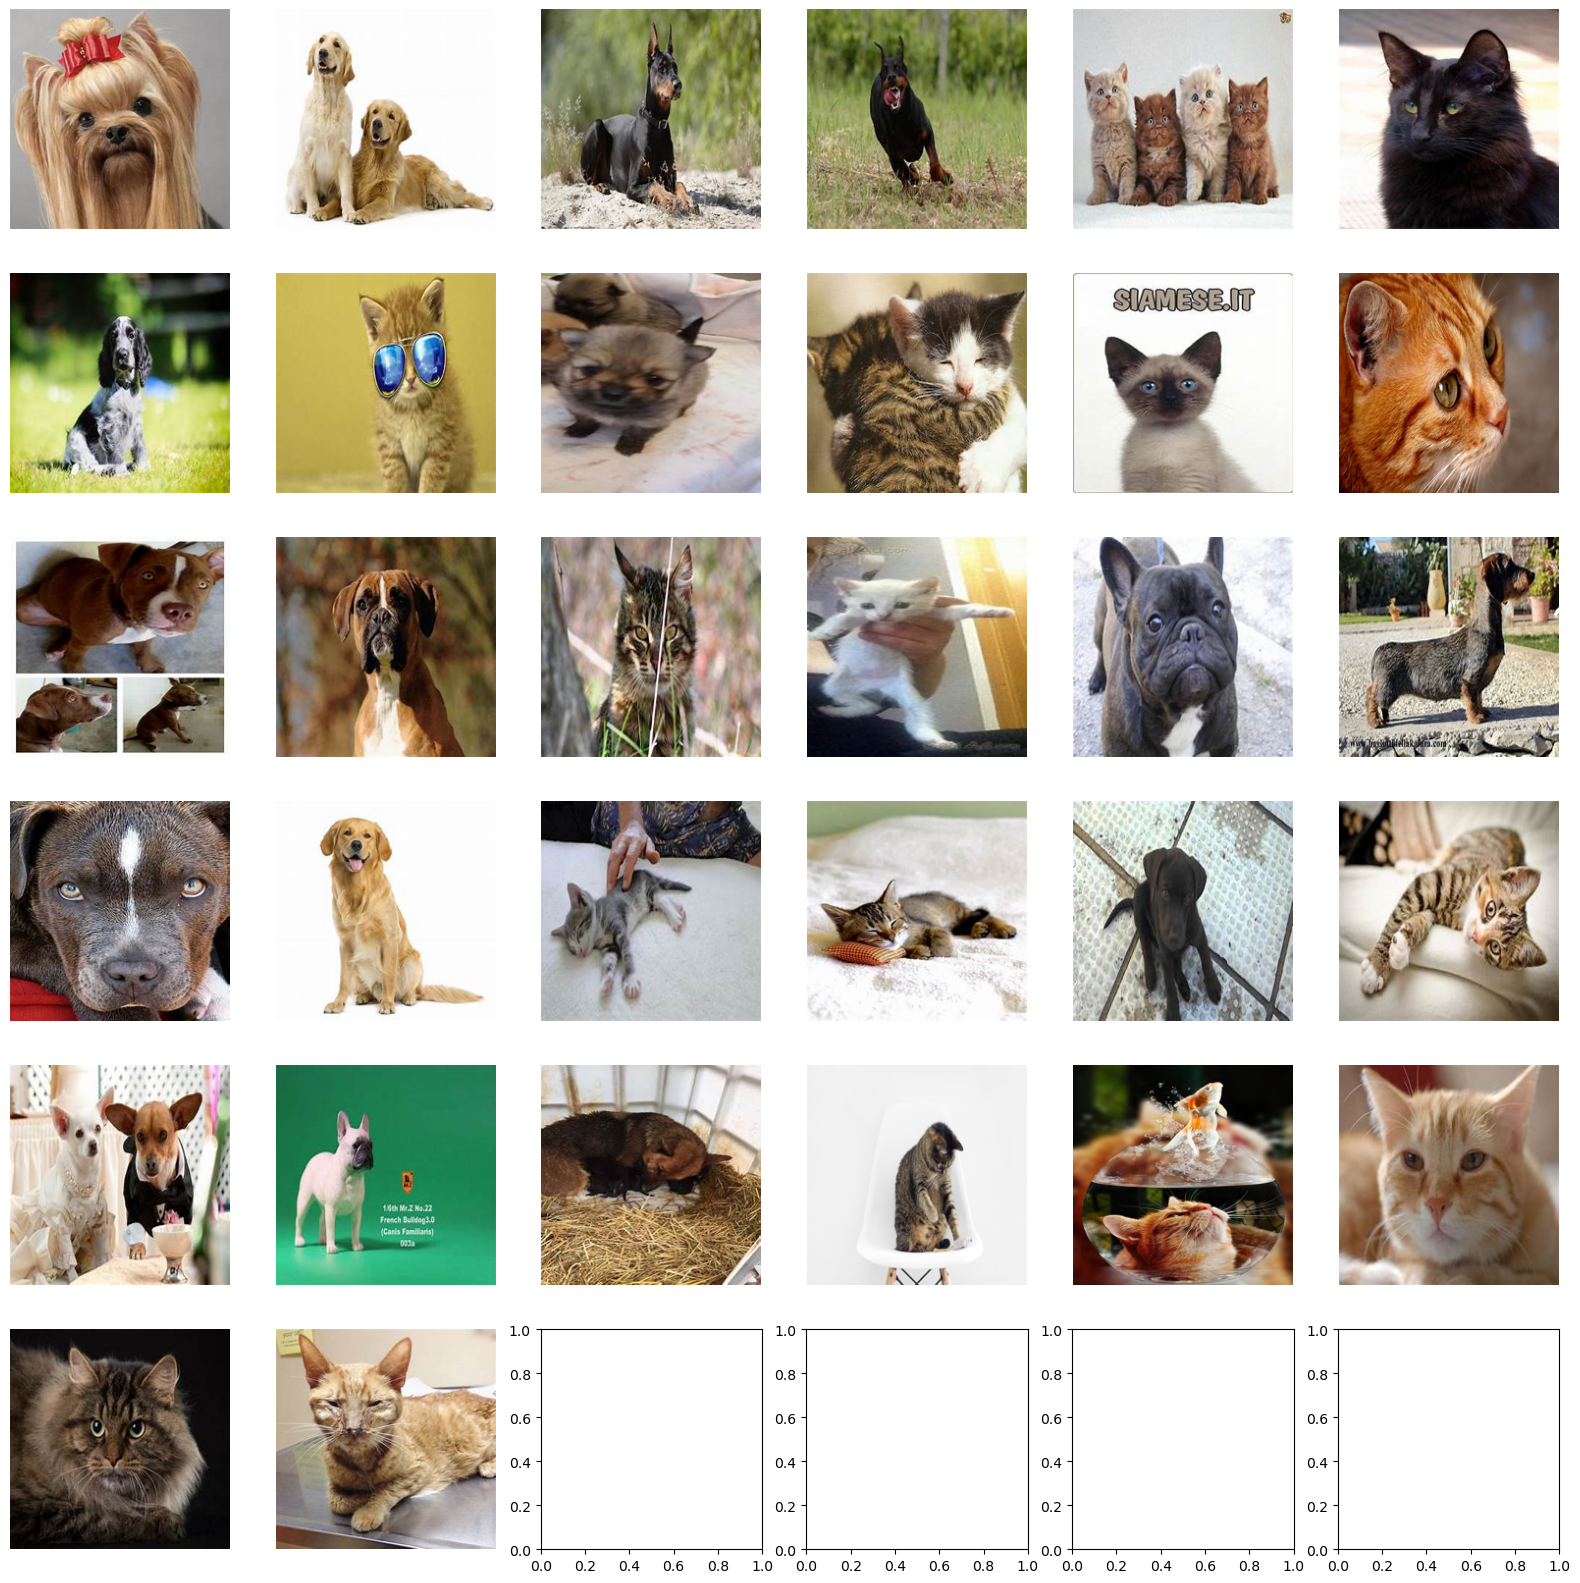

In [4]:
batch_generator.visualize_batch()

In [5]:
batch_generator.invert_label(2)

data label out of range, the model knows only the following classes:  ['dog', 'cat']


In [6]:
sum(batch_generator.all_lengths)

6531

In [7]:
batch_generator.all_lengths,batch_generator.classes,batch_generator.class_map

([4863, 1668], ['dog', 'cat'], {'dog': 0, 'cat': 1})

In [180]:
batch_generator.batch_img_paths

array(['C:\\Users\\ayhan\\Desktop\\ml-collection\\data\\ten_animals\\raw-img\\cat\\ea36b40820f3063ed1584d05fb1d4e9fe777ead218ac104497f5c978a7eebdbb_640.jpg',
       'C:\\Users\\ayhan\\Desktop\\ml-collection\\data\\ten_animals\\raw-img\\dog\\OIP-WnhuXNQiH9YlRERyt_H1UgHaFj.jpeg',
       'C:\\Users\\ayhan\\Desktop\\ml-collection\\data\\ten_animals\\raw-img\\dog\\OIP-UMY3MrdrZ_OzFEL7qyb_pQHaEv.jpeg',
       'C:\\Users\\ayhan\\Desktop\\ml-collection\\data\\ten_animals\\raw-img\\cat\\ea36b7062af4043ed1584d05fb1d4e9fe777ead218ac104497f5c978a7eebdbb_640.jpg',
       'C:\\Users\\ayhan\\Desktop\\ml-collection\\data\\ten_animals\\raw-img\\cat\\730.jpeg',
       'C:\\Users\\ayhan\\Desktop\\ml-collection\\data\\ten_animals\\raw-img\\dog\\OIP-0d7hpjwVocPjQXWE67RdKwHaFj.jpeg',
       'C:\\Users\\ayhan\\Desktop\\ml-collection\\data\\ten_animals\\raw-img\\dog\\OIP-6XZo5Xtu-krMjGU7kqe3HAHaEK.jpeg',
       'C:\\Users\\ayhan\\Desktop\\ml-collection\\data\\ten_animals\\raw-img\\cat\\599.jpeg',
       'C:\\

In [181]:
batch_generator.batch_matrix

array([[[[ 97,   7,  56, ..., 224,  40,  75],
         [133,   7,  55, ..., 239,  41, 115],
         [155,   7,  60, ..., 242,  35,  18]],

        [[ 94,   5,  53, ..., 221,  76,  87],
         [130,   5,  52, ..., 236,  77, 126],
         [152,   5,  57, ..., 239,  71,  27]],

        [[ 92,   5,  52, ..., 219,  83,  86],
         [128,   5,  51, ..., 234,  84, 124],
         [150,   5,  56, ..., 237,  78,  23]],

        ...,

        [[225,   5, 204, ..., 130,  55,  63],
         [255,   5, 202, ..., 131,  73,  99],
         [255,   5, 205, ..., 126,  22,   0]],

        [[236,   5, 206, ..., 189,  51,  62],
         [255,   5, 204, ..., 189,  68,  99],
         [254,   5, 207, ..., 187,  19,   0]],

        [[247,   6, 216, ..., 181,  50,  63],
         [254,   6, 214, ..., 181,  64, 101],
         [253,   6, 217, ..., 181,  17,   0]]],


       [[[ 94,   7,  59, ..., 236,  47,  70],
         [130,   7,  58, ..., 251,  48, 106],
         [151,   7,  63, ..., 254,  42,  35]],

    

In [182]:
batch_generator = ImageBatchGenerator({"dog":dogs_path, "cat":cats_path},batch_size=12,network_input_size=(50,50))

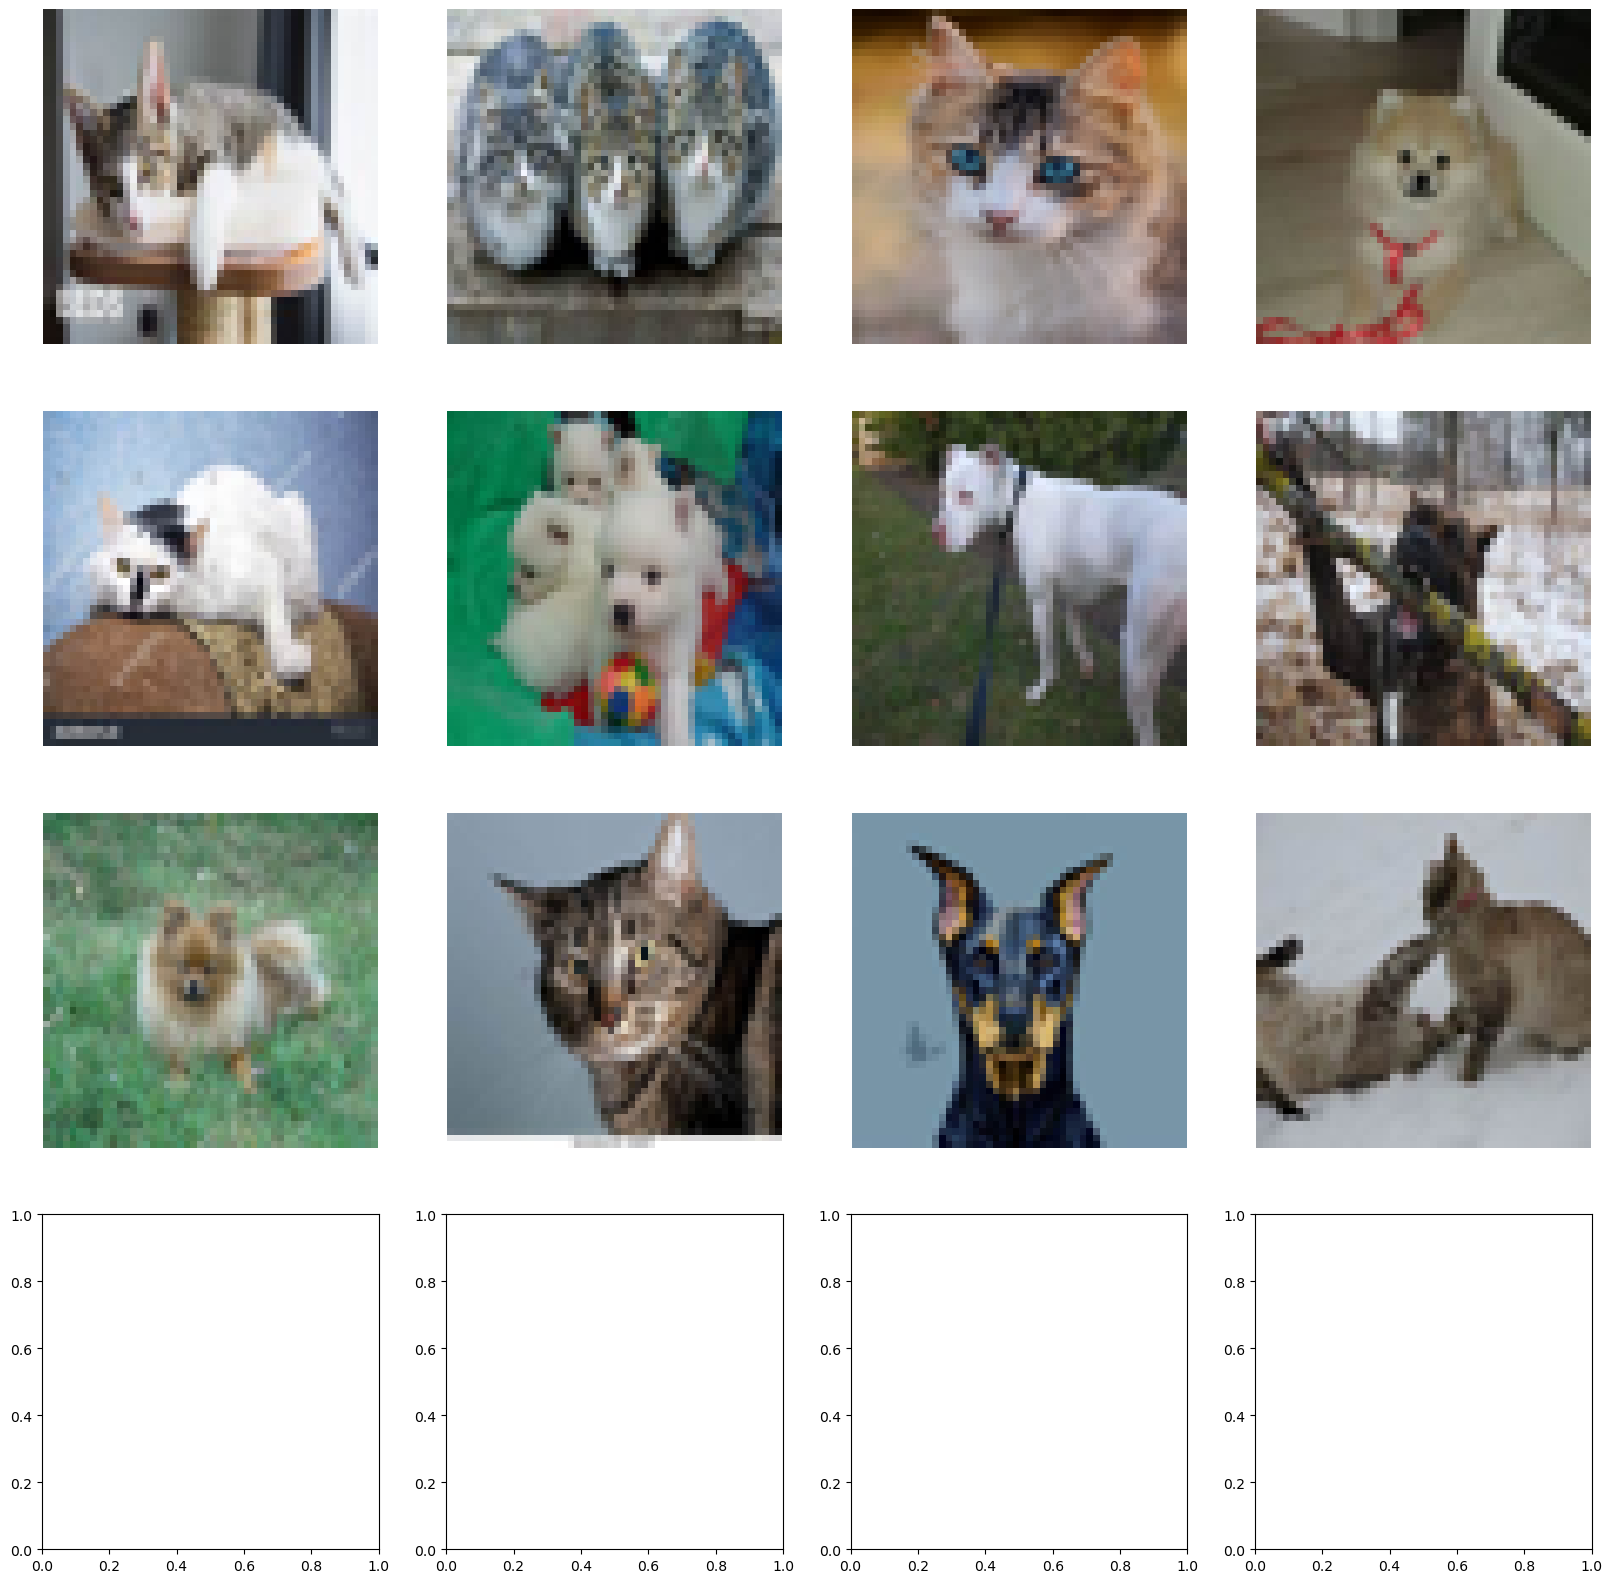

In [183]:
batch_generator.visualize_batch()

### now lets implement our own convolution layer

In [ ]:
"""
# He initialization
fan_in = 3 * 3 * 3
std = np.sqrt(2.0 / fan_in)
weights = np.random.randn(10, 3, 3) * std
weights

"""
# TESTING THE CONVOLUTION LOOP
"""
padded_image = np.zeros((100 + 2 * 1, 100+ 2 * 1, 3, 10, 64))
weights = np.random.randn(10, 3, 3)
biases = np.random.randn(10)
# now multiply the padded image with the weights
output = np.zeros((100, 100, 3, 10, 64))
for i in range(64):
    padded_img = padded_image[:, :, :, :, i]
    for c in range(3):
        for k in range(10):
            for y in range(100):
                for x in range(100):
                    x_start = x * 1
                    x_end = x_start + 3
                    y_start = y*1
                    y_end = y_start + 3
                    current_window = padded_img[x_start:x_end, y_start:y_end, c, k]
                    output[x, y, c, k, i] = np.sum(np.multiply(current_window, weights[k]))
"""


In [37]:
class ManualConvLayer:
    def __init__(self,kernel_shape=(3,3),kernel_count:int=5,stride:int=1,padding:int=0) -> None:
        self.kernel_x , self.kernel_y = kernel_shape
        self.kernel_count = kernel_count
        self.stride = stride
        self.padding = padding
        # here kernels and their corresponding biases are learned parameters
        # He initialization
        fan_in = self.kernel_x * self.kernel_y * 3
        stddev = np.sqrt(2 / fan_in)
        self.weights = np.random.randn(self.kernel_count, self.kernel_x, self.kernel_y) * stddev
        self.biases = np.random.randn(self.kernel_count)

    def forward(self,img_batch:np.ndarray) -> np.ndarray:
        img_x,img_y,img_channels,batch_size = img_batch.shape

        self.output_x = (img_x - self.kernel_x + 2 * self.padding) // self.stride + 1
        self.output_y = (img_y - self.kernel_y + 2 * self.padding) // self.stride + 1
        self.output =  np.zeros((self.output_x, self.output_y, img_channels, self.kernel_count, batch_size))
        self.weights = np.nan_to_num(self.weights)
        self.biases = np.nan_to_num(self.biases)
        self.padded_image = np.zeros((img_x + 2 * self.padding, img_y + 2 * self.padding, img_channels, self.kernel_count, batch_size))
        
        # padd all batch images for each kernel, think it of as parallel strings.
        for k in range(self.kernel_count):
            self.padded_image[self.padding:img_x + self.padding, self.padding:img_y + self.padding, :, k, :] = img_batch

        # TODO: vectorize - parallelize this loop
        for i in range(batch_size):
            padded_img = self.padded_image[:, :, :, :, i]
            for c in range(img_channels):
                for k in range(self.kernel_count):
                    for y in range(self.output_y):
                        for x in range(self.output_x):
                            # adjusting the current sliding window
                            x_start = x * self.stride
                            x_end = x_start + self.kernel_x
                            y_start = y*self.stride
                            y_end = y_start + self.kernel_y
                            current_window = padded_img[x_start:x_end, y_start:y_end, c, k]
                            self.output[x, y, c, k, i] = np.sum(np.multiply(current_window, self.weights[k])) + self.biases[k].astype("float64")

        # now we need to sum the convolutions over all channels: axis=2
        self.output = self.output.sum(axis=2)
        # now lets save the input as well (for backpropagation)
        self.input = img_batch
        return self.output
        



In [40]:
img_batch = ImageBatchGenerator({"dog":dogs_path, "cat":cats_path},batch_size=8,network_input_size=(100,100))
#img_batch.visualize_batch()
conv_layer = ManualConvLayer(kernel_shape=(3,3),kernel_count=5,padding=2)
output = conv_layer.forward(img_batch.batch_matrix)
output.shape # 4 dimensions expected:  x,y,kernel_count,batch_size 

(102, 102, 5, 8)

first kernel weights:
 [[-0.54632748 -0.08050666 -0.20066457]
 [-0.0705276   0.43606154 -0.12464293]
 [ 0.11361269  0.58303166 -0.11381749]]
first kernel biases:
 -0.32670861872371215
class of the input image cat


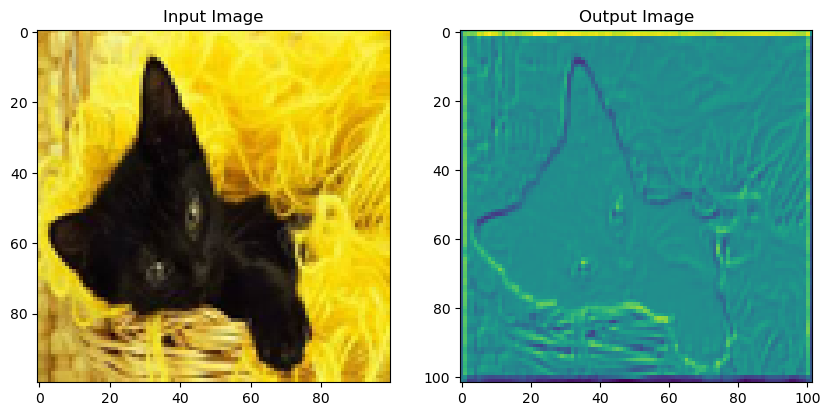

In [54]:
# lets print out the first kernel weights and biases
print(f"first kernel weights:\n {conv_layer.weights[0]}")
print(f"first kernel biases:\n {conv_layer.biases[0]}")

print("class of the input image", img_batch.batch_labels[0])
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# lets visualize the first image in the input batch
axes[0].imshow(img_batch.batch_matrix[:, :, :, 0]) 
axes[0].set_title("Input Image")


# now lets visualize the first image in the output batch
axes[1].imshow(output[:, :, 0, 0]) 
axes[1].set_title("Output Image")

plt.show()

In [55]:
conv_layer2 = ManualConvLayer(kernel_shape=(5,5),kernel_count=15,padding=1)
output2 = conv_layer2.forward(output)
